# Data Generating Process

In [1]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="colorblind")

In [10]:
def random_walk(obs=100, m=0, stdev=0.5, d=1):
    """
    :param: obs: number of observations
    :param: m: mean
    :param: stdev: standard deviation
    :param: d: number of dimensions
    """
    return np.cumsum(np.random.normal(m, stdev, (obs, d)))

def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def heteroscedasticity(obs=100, m=0, rate=0.01):
    sigma = rate * np.arange(obs) 
    return np.random.normal(loc=m, scale=sigma)

def linear_trend(obs=100, d=1, y_start=0, y_stop=10):
    return np.linspace(start=y_start, stop=y_stop, num=obs).reshape(-1, 1).flatten()

def seasonality(obs=100, d=1, period=7, y_max=2):
    """
    :param: obs: number of observations
    :param: d: number of dimensions
    :param: period: period of the seasonal component
    :param: y_max: maximum value of the seasonal component
    """
    t = np.arange(obs)
    return y_max * np.sin(2 * np.pi * t / period).reshape(-1, d).flatten()

def structural_break(t, break_point=50, size=2):
    """:param: t: time points
    :param: break_point: index where the structural break occurs
    """
    t[break_point:] += size 
    return t

def segmented_trend(obs=100, y_start=0, y_stop=10, d=1, 
                    segment_start=0.5, segment_end=0.7, segment_y_start=1, segment_y_stop=5):
    segment_start = int(segment_start*obs)
    segment_end = int(segment_end*obs)
    t1 = linear_trend(segment_start, d, y_start=y_start, y_stop=segment_y_start)
    t2 = linear_trend(segment_end - segment_start, d, y_start=segment_y_start, y_stop=segment_y_stop)
    t3 = linear_trend(obs - segment_end, d, y_start=segment_y_stop, y_stop=y_stop)
    t = np.concatenate([t1, t2, t3])
    return t

def anomalies(t, anomaly_point=70, size=2):
    t[anomaly_point] += size  
    return t

# White noise

<Axes: >

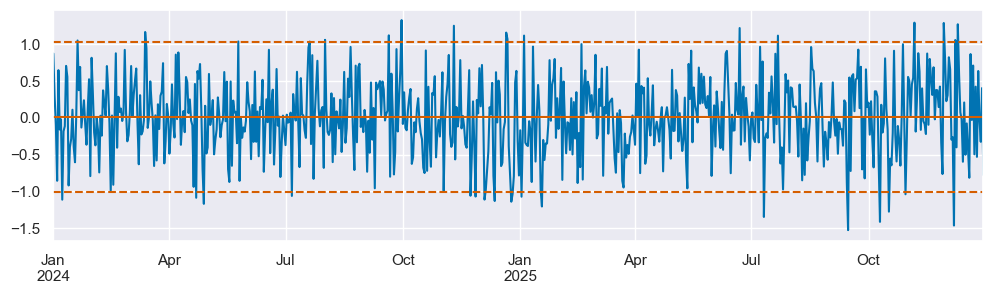

In [3]:
nobs = 365*2
dts = pd.date_range(start="2024-01-01", periods=nobs)
df = pd.DataFrame(white_noise(nobs), index=dts)
df.columns = ["white noise"]

df.loc[:,"Mean"] = df["white noise"].mean()
df.loc[:, "2*Stdev"] = df["Mean"] + 2 * df["white noise"].std()
df.loc[:, "-2*Stdev"] = df["Mean"] - 2 * df["white noise"].std()

df.plot(y=["white noise", "Mean", "2*Stdev", "-2*Stdev"], 
         figsize=(12, 3), 
         style={"Mean": "r", "2*Stdev": "--r", "-2*Stdev": "--r"}, 
         legend=False,
         use_index=True)

# Red noise

<Axes: >

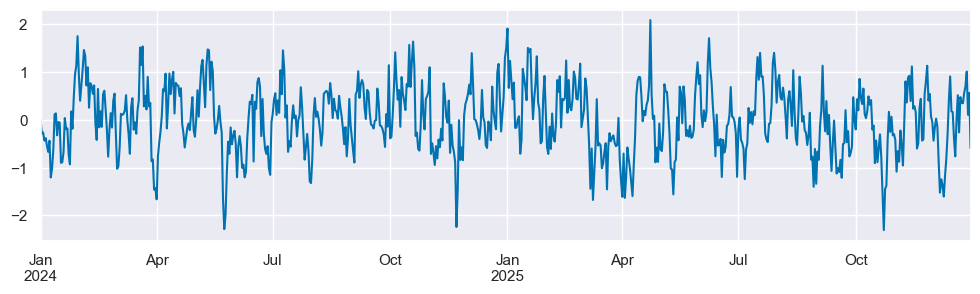

In [4]:
df["Red noise"] = red_noise(nobs, corr=0.7)

df["Red noise"].plot(figsize=(12, 3), use_index=True)

# Linear trend

<Axes: >

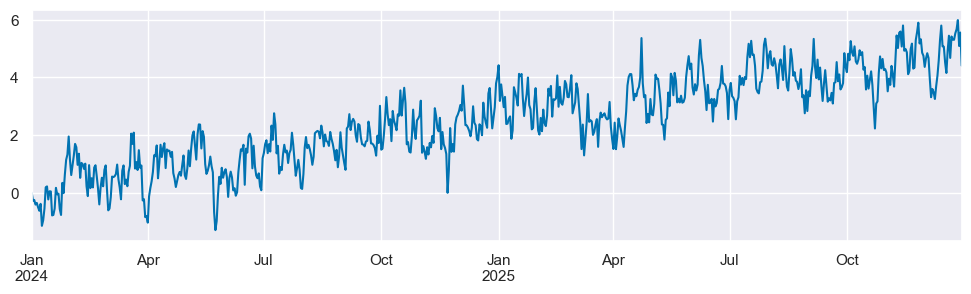

In [5]:
trend = linear_trend(nobs, y_start=0, y_stop=5)
df["Linear trend + RN"] = trend + df["Red noise"]

df["Linear trend + RN"].plot(figsize=(12, 3), use_index=True)

# Heteroskedasticity

<Axes: >

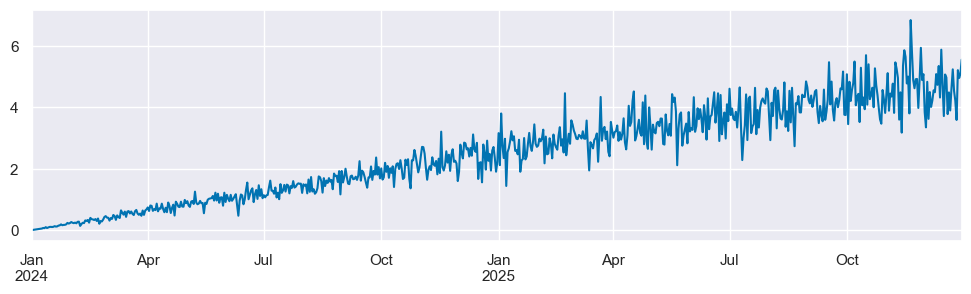

In [11]:
trend = linear_trend(nobs, y_start=0, y_stop=5)
h = heteroscedasticity(nobs, rate=0.001)

df["Linear trend + heteroscedasticity"] = trend + h
df["Linear trend + heteroscedasticity"].plot(figsize=(12, 3), use_index=True)

# Seasonality

<Axes: >

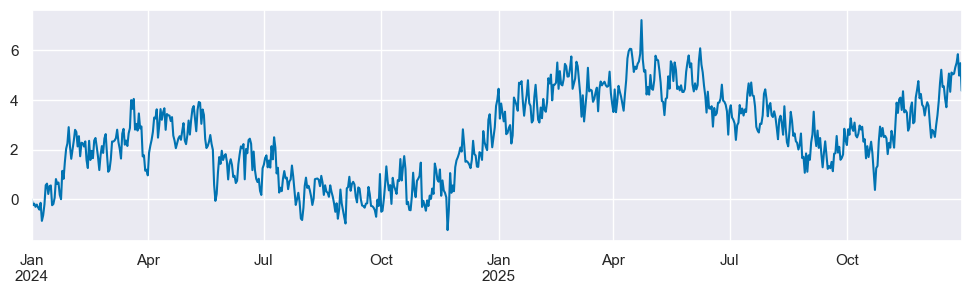

In [7]:
seasonal = seasonality(nobs, period=365, y_max=2)
df["Seasonality + Trend + RN"] = seasonal + df["Linear trend + RN"]

df["Seasonality + Trend + RN"].plot(figsize=(12, 3), use_index=True)

# Anomalies

<Axes: >

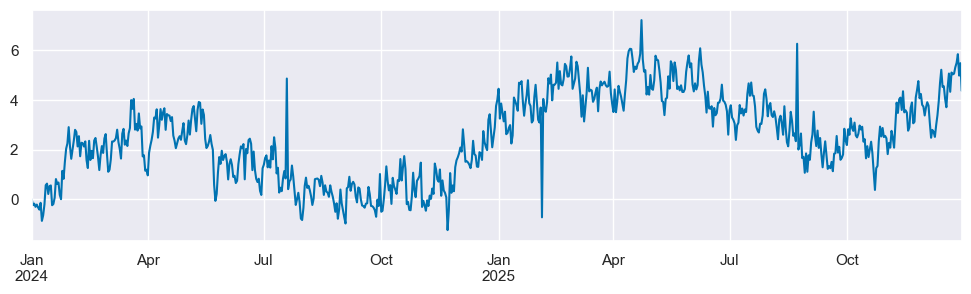

In [8]:
# add three anomalies
anomalous = anomalies(df["Seasonality + Trend + RN"].values.copy(), anomaly_point=200, size=4)
anomalous = anomalies(anomalous, anomaly_point=400, size=-4)
anomalous = anomalies(anomalous, anomaly_point=600, size=4)
df["Seasonality + Trend + RN + Anomaly"] = anomalous

df["Seasonality + Trend + RN + Anomaly"].plot(figsize=(12, 3), use_index=True)

# Structural break

<Axes: >

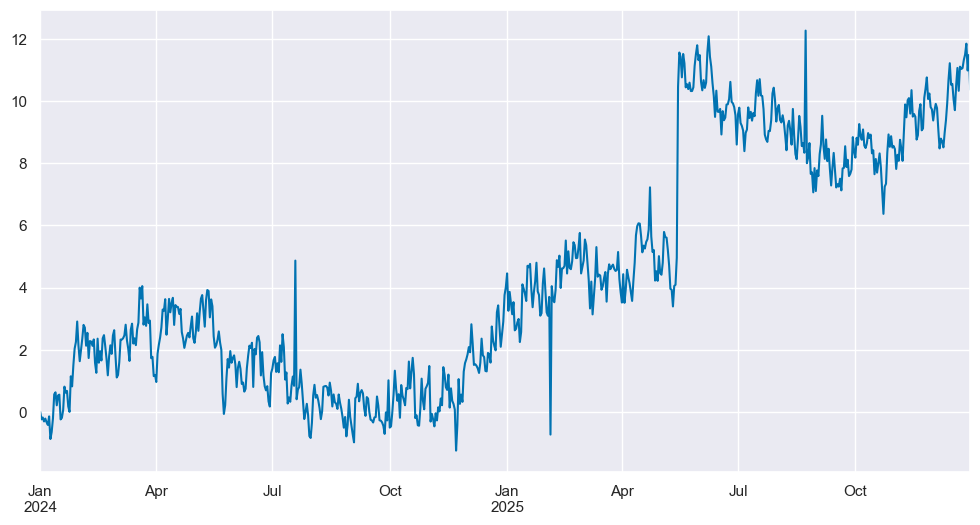

In [9]:
df["Seasonality + Trend + RN + Anomaly + Structural Break"] = structural_break(
    df["Seasonality + Trend + RN + Anomaly"].values.copy(), break_point=500, size=6)

df["Seasonality + Trend + RN + Anomaly + Structural Break"].plot(figsize=(12, 6), use_index=True)

# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf